# Key Efficiency Comparison Main Notebook.

This contains the comparisons of SR, MD and GBSR for the paper. 

We explore in this order:
- SR
  - Sanity checks against Van Assche (2004) for m=1 and m=4
  - Plot achievable key rates for m = 1, 2, 3, 4, 5 over distance (for set parameters, see below)
- MD
- GBSR
- Classical Channel Usage

In [10]:
# imports etc
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize, minimize_scalar
import matplotlib.pyplot as plt

import importlib

SR = importlib.import_module('guard_band_postselection.SR').SR
GBSR = importlib.import_module('guard_band_postselection.GBSR').GBSR
MD = importlib.import_module('guard_band_postselection.MD').MD

LDPCSimpleModel = importlib.import_module('guard_band_postselection.code_efficiency').LDPCSimpleModel
make_eta_c_provider = importlib.import_module('guard_band_postselection.code_efficiency').make_eta_c_provider


### Van Assche Sanity Checks

See vanassche-2004.

In [11]:
snr_target = 3.0
# With heterodyne SNR definition SNR = (0.5 * T * V_mod) / (1 + 0.5 * xi).
# Choosing T=1, xi=0, V_mod=6 gives SNR about 3.
modulation_variance = 6.0
transmittance = 1.0
excess_noise = 0.0

sr = SR(
    m=1,
    modulation_variance=modulation_variance,
    transmittance=transmittance,
    excess_noise=excess_noise,
    code_efficiency=1.0,
)

tau = [-float('inf'), 0.0, float('inf')]
error_rate = sr._evaluate_slice_error_rates(tau)[0]
h_error = -error_rate * np.log2(error_rate) - (1 - error_rate) * np.log2(1 - error_rate)
secret_bits = 1.0 - h_error

print(f'SNR (target 3) = {sr.SNR:.6f}')
print(f'Slice error e (expected ~0.167) = {error_rate:.6f}')
print(f'binary entropy h(e) (expected ~0.65) = {h_error:.6f}')
print(f'Net private bits 1 - h(e) (expected ~0.35) = {secret_bits:.6f}')


SNR (target 3) = 3.000000
Slice error e (expected ~0.167) = 0.165717
binary entropy h(e) (expected ~0.65) = 0.647813
Net private bits 1 - h(e) (expected ~0.35) = 0.352187


In [12]:
shot_noise = 1 / 3
sr = SR(
    m=4,
    modulation_variance=1.0,
    transmittance=2.0,
    excess_noise=0.0,
    code_efficiency=1.0,
    shot_noise=shot_noise,
)

# Interval boundaries from Fig. 2 of Van Assche et al. (2004)
# (symmetric and expressed for sigma = 1).
tau = [-np.inf, -2.347, -1.808, -1.411, -1.081, -0.768, -0.514, -0.254,
        0.0, 0.254, 0.514, 0.768, 1.081, 1.411, 1.808, 2.347, np.inf]

errors = sr._evaluate_slice_error_rates(tau, bit_assignment="binary")
metrics = sr.evaluate_reconciliation_efficiency(tau, code_efficiency=1.0, bit_assignment="binary")
net_bits = metrics["bits_sent"] - metrics["bits_leaked"]

print("Slice error rates (target [0.496, 0.468, 0.25, 0.02]):")
for idx, e in enumerate(errors, start=1):
    print(f"  e_{idx} = {e:.6f}")

print(f"H(T(X)) = {metrics['quantisation_entropy']:.6f} bits")
print(f"sum h(e_i) = {metrics['bits_leaked']:.6f} bits")
print(f"Net private bits H - sum h = {net_bits:.6f} bits")


Slice error rates (target [0.496, 0.468, 0.25, 0.02]):
  e_1 = 0.488254
  e_2 = 0.462273
  e_3 = 0.250412
  e_4 = 0.021041
H(T(X)) = 3.783576 bits
sum h(e_i) = 2.954668 bits
Net private bits H - sum h = 0.828909 bits


In [13]:
shot_noise = 1 / 3
sr_opt = SR(
    m=4,
    modulation_variance=1.0,
    transmittance=2.0,
    excess_noise=0.0,
    code_efficiency=1.0,
    shot_noise=shot_noise,
)

# Parameterise the positive boundaries via cumulative sums of exp(params)
# to preserve ordering and symmetry around zero.
def build_tau(params):
    increments = np.exp(params)
    positives = np.cumsum(increments)
    return np.concatenate(([-np.inf], -positives[::-1], [0.0], positives, [np.inf]))

def neg_net_bits(params):
    tau = build_tau(params)
    metrics = sr_opt.evaluate_reconciliation_efficiency(
        tau, code_efficiency=1.0, bit_assignment="binary"
    )
    net_bits = metrics["bits_sent"] - metrics["bits_leaked"]
    return -net_bits

initial_positive = np.array([0.25, 0.5, 0.8, 1.1, 1.4, 1.8, 2.35])
initial_increments = np.diff(np.concatenate(([0.0], initial_positive)))
params0 = np.log(np.clip(initial_increments, 1e-4, None))

opt_result = minimize(neg_net_bits, params0, method="L-BFGS-B")
opt_tau = build_tau(opt_result.x)
opt_metrics = sr_opt.evaluate_reconciliation_efficiency(
    opt_tau, code_efficiency=1.0, bit_assignment="binary"
)
opt_errors = sr_opt._evaluate_slice_error_rates(opt_tau, bit_assignment="binary")
opt_net_bits = opt_metrics["bits_sent"] - opt_metrics["bits_leaked"]

print("Optimisation success:", opt_result.success)
print("Converged net private bits:", opt_net_bits)
print("Optimised positive boundaries:", opt_tau[9:-1])
print("Slice error rates:", opt_errors)
print(
    "Entropy H(T) =", opt_metrics["quantisation_entropy"],
    ", sum h(e) =", opt_metrics["bits_leaked"],
    ", net =", opt_net_bits,
)


Optimisation success: True
Converged net private bits: 0.8637404067988652
Optimised positive boundaries: [0.35083787 0.69861268 1.05094613 1.40078043 1.7590074  2.12338695
 2.55327165]
Slice error rates: [0.49633847 0.45023671 0.16311152 0.00483816]
Entropy H(T) = 3.542421057802714 , sum h(e) = 2.678680651003849 , net = 0.8637404067988652


The previous two cells reproduce the slice profile reported in Van Assche et al. (2004) and then optimise the symmetric interval boundaries directly. The table below compares the two configurations (all values in bits unless stated).

| quantity | published t (Fig. 2) | optimised t |
| --- | --- | --- |
| $\big(T(X)\big)$ | $3.7836$ | $3.5424$ |
| $\sum_i h_2(e_i)$ | $2.9547$ | $2.6787$ |
| net private bits $H-\sum_i h_2$ | $0.8289$ | $0.8637$ |
| slice error rates $[e_1,e_2,e_3,e_4]$ | $[0.4883, 0.4623, 0.2504, 0.0210]$ | $[0.4963, 0.4502, 0.1631, 0.0048]$ |
| positive boundaries $	au_9\dots	au_{15}$ | $[0.254, 0.514, 0.768, 1.081, 1.411, 1.808, 2.347]$ | $[0.351, 0.699, 1.051, 1.401, 1.759, 2.123, 2.553]$ |

The optimisation (with $N_0 = 1/3$ and $\text{SNR} = 3$) tightens the entropy/leak balance by roughly $0.035$ bits per raw symbol compared to the published boundaries, while still yielding a consistent slice ordering. This is likely due to some subtelty somewhere, but as far as we're concerned, this is a pass.


# SR key rate optimisation

Here, we find the optimal key rates achievable (and corresponding reconciliation efficiencies) for m = 1, 2, 3, 4, 5 slices over a range of distances. The parameters are set below. This is done by optimising $V_\text{mod}$, and optimising the slice boundaries $\tau$ for each distance and m. For illustration, we also plot the Devetak-Winter equation, with reconciliation efficiency $\eta = 0.95$. 

In [14]:
# Parameters
v_mod_bounds = (0.001, 30.0)
excess_noise = 0.001
Delta_QCT = 0.0
eta_c = 0.97  # coding efficiency (constant for now)
distances_km = np.logspace(-2, 2, num=100)

def fibre_transmittance(distance_km, loss_db_per_km=0.2):
    """Return the channel transmittance for a fibre segment of length `distance_km`."""
    return 10 ** (-loss_db_per_km * distance_km / 10)


## Devetak-Winter

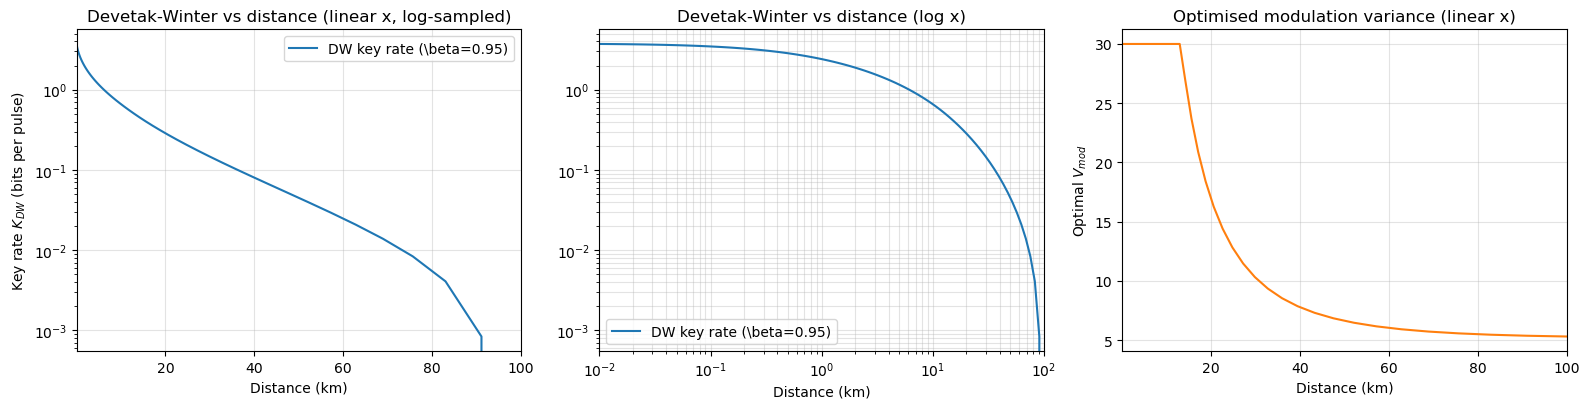

In [15]:
beta_dw = 0.97
optimal_vmods_DW = []
dw_key_rates = []
mutual_infos = []
holevo_terms = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_dw_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_devetak_winter(beta=beta_dw)

    result = minimize_scalar(neg_dw_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(f'V_mod optimisation failed at distance {distance_km} km: {result.message}')
    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    dw_rate = sr_opt.evaluate_devetak_winter(beta=beta_dw)
    dw_key_rates.append(dw_rate)
    mutual_infos.append(sr_opt.I_AB)
    holevo_terms.append(sr_opt._holevo_with_qct())

# --- plotting: key rate (linear x), key rate (log x), V_mod (linear x) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax_k_lin, ax_k_log, ax_vmod = axes

# Key rate linear x (points are log-sampled)
ax_k_lin.plot(distances_km, dw_key_rates, label='DW key rate (\\beta=0.95)')
ax_k_lin.set_xlabel('Distance (km)')
ax_k_lin.set_ylabel('Key rate $K_{DW}$ (bits per pulse)')
ax_k_lin.set_title('Devetak-Winter vs distance (linear x, log-sampled)')
ax_k_lin.set_yscale('log')
ax_k_lin.set_xlim(1e-2, 1e2)
ax_k_lin.grid(True, alpha=0.35)
ax_k_lin.legend()

# Key rate log x
ax_k_log.plot(distances_km, dw_key_rates, label='DW key rate (\\beta=0.95)')
ax_k_log.set_xlabel('Distance (km)')
ax_k_log.set_title('Devetak-Winter vs distance (log x)')
ax_k_log.set_yscale('log')
ax_k_log.set_xscale('log')
ax_k_log.set_xlim(1e-2, 1e2)
ax_k_log.grid(True, which='both', alpha=0.35)
ax_k_log.legend()

# V_mod linear x
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimised modulation variance (linear x)')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

fig.tight_layout()

## SR

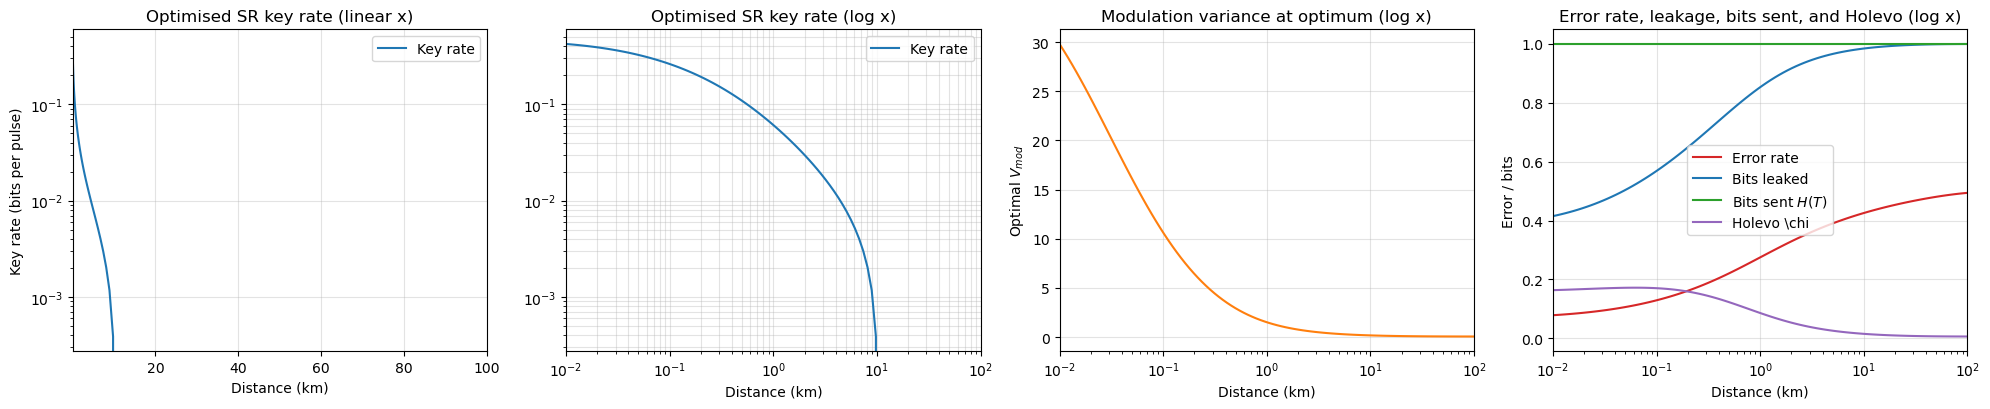

In [16]:
# --- compute (unchanged) ---
tau_sr_m1 = [-np.inf, 0.0, np.inf]

optimal_vmods_DW = []
optimal_key_rates = []
optimal_etas = []
optimal_error_rates = []
optimal_bits_leaked = []
optimal_bits_sent = []
optimal_holevo = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)

    result = minimize_scalar(neg_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(
            f'V_mod optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)
    optimal_key_rates.append(key_rate)

    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1)
    optimal_etas.append(metrics["eta"])
    slice_info = metrics["slices"][0]
    optimal_error_rates.append(slice_info["error_rate"])
    optimal_bits_leaked.append(metrics["bits_leaked"])
    optimal_bits_sent.append(metrics["bits_sent"])
    optimal_holevo.append(sr_opt._holevo_with_qct())

# --- plotting: 4 panels -> key (linear x), key (log x), V_mod (linear x), leak metrics (linear x)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax_key_lin, ax_key_log, ax_vmod, ax_leak = axes

# Key rate linear x (data sampled on a log grid)
ax_key_lin.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate log x
ax_key_log.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# V_mod switch x axis to log (was linear); remove marker
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Modulation variance at optimum (log x)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Error / leakage / bits / Holevo switch x axis to log (was linear); remove markers
ax_leak.plot(distances_km, optimal_error_rates, color='tab:red', label='Error rate')
ax_leak.plot(distances_km, optimal_bits_leaked, color='tab:blue', label='Bits leaked')
ax_leak.plot(distances_km, optimal_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_leak.plot(distances_km, optimal_holevo, color='tab:purple', label='Holevo \\chi')
ax_leak.set_xlabel('Distance (km)')
ax_leak.set_ylabel('Error / bits')
ax_leak.set_title('Error rate, leakage, bits sent, and Holevo (log x)')
ax_leak.set_xscale('log')
ax_leak.set_xlim(1e-2, 1e2)
ax_leak.grid(True, alpha=0.35)
ax_leak.legend()

fig.tight_layout()

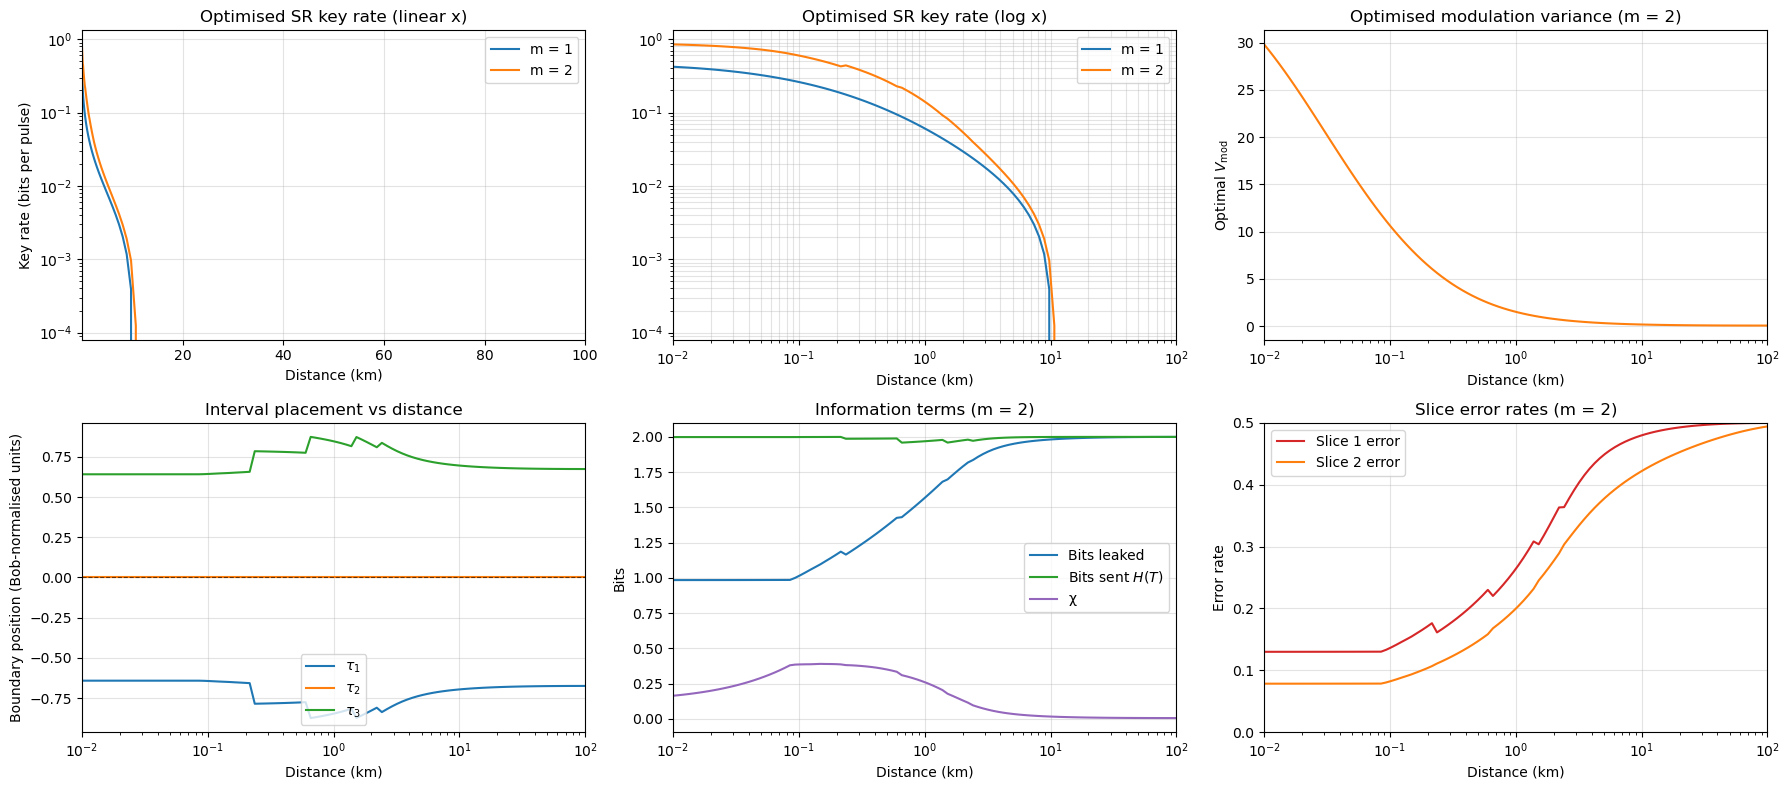

In [17]:
m = 2
raw_param_guess = np.array([0.5, np.log(0.8)], dtype=float)

def _unpack_params_m2(raw_params):
    v_mod = float(raw_params[0])
    tau_positive = float(np.exp(raw_params[1]))
    tau_arr = [-np.inf, -tau_positive, 0.0, tau_positive, np.inf]
    return v_mod, tau_positive, tau_arr

optimal_vmods_m2 = []
optimal_tau1 = []
optimal_key_rates_m2 = []
optimal_etas_m2 = []
optimal_error_rates_stage0 = []
optimal_error_rates_stage1 = []
optimal_bits_leaked_m2 = []
optimal_bits_sent_m2 = []
optimal_holevo_m2 = []
tau1_positions = []
tau2_positions = []
tau3_positions = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_key_rate(raw_params):
        v_mod, _, tau_arr = _unpack_params_m2(raw_params)
        sr_instance = SR(
            m=m,
            modulation_variance=v_mod,
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_arr)

    x0 = np.array(
        [np.clip(raw_param_guess[0], *v_mod_bounds), raw_param_guess[1]],
        dtype=float,
    )

    result = minimize(
        neg_key_rate,
        x0=x0,
        method='L-BFGS-B',
        bounds=(v_mod_bounds, (None, None)),
        options={'ftol': 1e-9},
    )
    if not result.success:
        raise RuntimeError(
            f'Joint optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt, tau1_opt, tau_arr_opt = _unpack_params_m2(result.x)
    raw_param_guess = result.x.copy()

    sr_opt = SR(
        m=m,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_arr_opt)
    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_arr_opt)

    optimal_vmods_m2.append(float(v_opt))
    optimal_tau1.append(float(tau1_opt))
    optimal_key_rates_m2.append(float(key_rate))
    optimal_etas_m2.append(metrics['eta'])

    slice_metrics = metrics['slices']
    optimal_error_rates_stage0.append(slice_metrics[0]['error_rate'])
    optimal_error_rates_stage1.append(slice_metrics[1]['error_rate'])

    optimal_bits_leaked_m2.append(metrics['bits_leaked'])
    optimal_bits_sent_m2.append(metrics['bits_sent'])
    optimal_holevo_m2.append(sr_opt._holevo_with_qct())

    normalised_boundaries = np.array([-tau1_opt, 0.0, tau1_opt], dtype=float)
    tau1_positions.append(normalised_boundaries[0])
    tau2_positions.append(normalised_boundaries[1])
    tau3_positions.append(normalised_boundaries[2])

# --- plotting: 2x3 grid (top row key rates + V_mod, bottom row taus + leakage + errors) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

# Key rate - linear x (include m=1 baseline) -- keep linear for the first subplot
ax_key_lin.plot(distances_km, optimal_key_rates, label='m = 1')
ax_key_lin.plot(distances_km, optimal_key_rates_m2, label='m = 2')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate - log x (include m=1 baseline)
ax_key_log.plot(distances_km, optimal_key_rates, label='m = 1')
ax_key_log.plot(distances_km, optimal_key_rates_m2, label='m = 2')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# V_mod evolution -- remove marker; x axis log
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
ax_vmod.set_title('Optimised modulation variance (m = 2)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Decision boundary placement (unnormalised) -- remove markers; x axis log
ax_tau_plot.plot(distances_km, tau1_positions, label=r'$\tau_1$')
ax_tau_plot.plot(distances_km, tau2_positions, label=r'$\tau_2$')
ax_tau_plot.plot(distances_km, tau3_positions, label=r'$\tau_3$')
ax_tau_plot.set_xlabel('Distance (km)')
ax_tau_plot.set_ylabel('Boundary position (Bob-normalised units)')
ax_tau_plot.set_title('Interval placement vs distance')
ax_tau_plot.set_xscale('log')
ax_tau_plot.axhline(0.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax_tau_plot.set_xlim(1e-2, 1e2)
ax_tau_plot.grid(True, alpha=0.35)
ax_tau_plot.legend()

# Bits leaked / sent / Holevo -- remove markers; x axis log
ax_bits.plot(distances_km, optimal_bits_leaked_m2, color='tab:blue', label='Bits leaked')
ax_bits.plot(distances_km, optimal_bits_sent_m2, color='tab:green', label='Bits sent $H(T)$')
ax_bits.plot(distances_km, optimal_holevo_m2, color='tab:purple', label='χ')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits')
ax_bits.set_title('Information terms (m = 2)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)
ax_bits.legend()

# Error rates per slice -- remove markers; x axis log
ax_errors.plot(distances_km, optimal_error_rates_stage0, color='tab:red', label='Slice 1 error')
ax_errors.plot(distances_km, optimal_error_rates_stage1, color='tab:orange', label='Slice 2 error')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 2)')
ax_errors.set_xscale('log')
ax_errors.set_ylim(0.0, 0.5)
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend()

fig.tight_layout()


In [18]:
m = 3
initial_v_mod = 0.6
initial_positive_boundaries = np.array([0.9, 1.5, 2.5], dtype=float)
initial_increments = np.diff(np.concatenate(([0.0], initial_positive_boundaries)))
raw_param_guess = np.concatenate((
    [initial_v_mod],
    np.log(np.clip(initial_increments, 1e-6, None)),
), dtype=float)

def _unpack_params_m3(raw_params):
    v_mod = float(raw_params[0])
    increments = np.exp(raw_params[1:])
    positives = np.cumsum(increments)
    tau_arr = np.concatenate(([-np.inf], -positives[::-1], [0.0], positives, [np.inf]))
    return v_mod, positives, tau_arr

optimal_vmods_m3 = []
optimal_tau1_m3 = []  # smallest positive threshold
optimal_tau2_m3 = []  # middle positive threshold
optimal_tau3_m3 = []  # largest positive threshold
optimal_key_rates_m3 = []
optimal_etas_m3 = []
optimal_error_rates_stage0_m3 = []
optimal_error_rates_stage1_m3 = []
optimal_error_rates_stage2_m3 = []
optimal_bits_leaked_m3 = []
optimal_bits_sent_m3 = []
optimal_holevo_m3 = []

for distance_km in distances_km:
    T = fibre_transmittance(distance_km)

    def neg_key_rate(raw_params):
        v_mod, _, tau_arr = _unpack_params_m3(raw_params)
        sr_instance = SR(
            m=m,
            modulation_variance=v_mod,
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_arr)

    x0 = np.array(
        [np.clip(raw_param_guess[0], *v_mod_bounds), *raw_param_guess[1:]],
        dtype=float,
    )

    result = minimize(
        neg_key_rate,
        x0=x0,
        method='L-BFGS-B',
        bounds=(v_mod_bounds, (None, None), (None, None), (None, None)),
        options={'ftol': 1e-9},
    )
    if not result.success:
        raise RuntimeError(
            f'Joint optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt, tau_positive, tau_arr_opt = _unpack_params_m3(result.x)
    raw_param_guess = result.x.copy()

    sr_opt = SR(
        m=m,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_arr_opt)
    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_arr_opt)

    optimal_vmods_m3.append(float(v_opt))
    optimal_tau1_m3.append(float(tau_positive[0]))
    optimal_tau2_m3.append(float(tau_positive[1]))
    optimal_tau3_m3.append(float(tau_positive[2]))
    optimal_key_rates_m3.append(float(key_rate))
    optimal_etas_m3.append(metrics['eta'])

    slice_metrics = metrics['slices']
    optimal_error_rates_stage0_m3.append(slice_metrics[0]['error_rate'])
    optimal_error_rates_stage1_m3.append(slice_metrics[1]['error_rate'])
    optimal_error_rates_stage2_m3.append(slice_metrics[2]['error_rate'])

    optimal_bits_leaked_m3.append(metrics['bits_leaked'])
    optimal_bits_sent_m3.append(metrics['bits_sent'])
    optimal_holevo_m3.append(sr_opt._holevo_with_qct())

# Prepare arrays for plotting (normalised to Bob's variance via the tau parameters)
tau1_arr = np.array(optimal_tau1_m3)
tau2_arr = np.array(optimal_tau2_m3)
tau3_arr = np.array(optimal_tau3_m3)
tau_zero_arr = np.zeros_like(tau1_arr)

# --- plotting: same 2x3 layout as the m = 2 case ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

# Key rate - linear x (include m=1 and m=2 baselines) -- keep linear for the first subplot
ax_key_lin.plot(distances_km, optimal_key_rates, label='m = 1')
ax_key_lin.plot(distances_km, optimal_key_rates_m2, label='m = 2')
ax_key_lin.plot(distances_km, optimal_key_rates_m3, label='m = 3')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate - log x (include m=1 and m=2 baselines)
ax_key_log.plot(distances_km, optimal_key_rates, label='m = 1')
ax_key_log.plot(distances_km, optimal_key_rates_m2, label='m = 2')
ax_key_log.plot(distances_km, optimal_key_rates_m3, label='m = 3')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# V_mod evolution -- remove marker; x axis log
ax_vmod.plot(distances_km, optimal_vmods_m3, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
ax_vmod.set_title('Optimised modulation variance (m = 3)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Decision boundary placement (Bob-normalised) -- remove markers; x axis log
ax_tau_plot.plot(distances_km, -tau3_arr, linestyle='--', label='-\\tau_3')
ax_tau_plot.plot(distances_km, -tau2_arr, linestyle='--', label='-\\tau_2')
ax_tau_plot.plot(distances_km, -tau1_arr, linestyle='--', label='-\\tau_1')
ax_tau_plot.plot(distances_km, tau_zero_arr, linestyle=':', color='black', label='0')
ax_tau_plot.plot(distances_km, tau1_arr, label='\\tau_1')
ax_tau_plot.plot(distances_km, tau2_arr, label='\\tau_2')
ax_tau_plot.plot(distances_km, tau3_arr, label='\\tau_3')
ax_tau_plot.set_xlabel('Distance (km)')
ax_tau_plot.set_ylabel('Boundary position (Bob-normalised units)')
ax_tau_plot.set_title('Interval placement vs distance (m = 3)')
ax_tau_plot.set_xscale('log')
ax_tau_plot.set_xlim(1e-2, 1e2)
ax_tau_plot.grid(True, alpha=0.35)
ax_tau_plot.legend(ncol=2)

# Bits leaked / sent / Holevo -- remove markers; x axis log
ax_bits.plot(distances_km, optimal_bits_leaked_m3, color='tab:blue', label='Bits leaked')
ax_bits.plot(distances_km, optimal_bits_sent_m3, color='tab:green', label='Bits sent $H(T)$')
ax_bits.plot(distances_km, optimal_holevo_m3, color='tab:purple', label='χ')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits')
ax_bits.set_title('Information terms (m = 3)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)
ax_bits.legend()

# Error rates per slice -- remove markers; x axis log
ax_errors.plot(distances_km, optimal_error_rates_stage0_m3, color='tab:red', label='Slice 1 error')
ax_errors.plot(distances_km, optimal_error_rates_stage1_m3, color='tab:orange', label='Slice 2 error')
ax_errors.plot(distances_km, optimal_error_rates_stage2_m3, color='tab:brown', label='Slice 3 error')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 3)')
ax_errors.set_xscale('log')
ax_errors.set_ylim(0.0, 0.5)
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend()

fig.tight_layout()


RuntimeError: Joint optimisation failed at distance 0.030538555088334154 km: ABNORMAL_TERMINATION_IN_LNSRCH

## Non-Constant $\eta_c(e)$ for SR $m =, 1, 2, 3$.

This uses the information given in the LDPC fitting notebook to extrapolate the experimental code efficiency $\eta_c(e; S_\text{fixed})$ for a fixed speed $S_\text{fixed}$ (in Mb/s). This is done for $m = 1, 2, 3$ slices. This should show that $m = 1$ is the most efficient at longer distances. First, we set this speed and plot $\eta_c(e)$.

In [ ]:
# speed = 1.0  # Mb/s decoder speed constraint

# ldpc_params_path = Path('experiments/ldpc_fitting/simple_model_params.json')
# ldpc_model = LDPCSimpleModel()
# ldpc_model.import_params(ldpc_params_path)
# ldpc_model.set_fixed_speed(speed)

# error_rates = np.linspace(0.0, 0.5, 400)
# eta_c_vals, _ = ldpc_model.eta_c_fixed_speed(error_rates * 100.0, speed)

# eta_c_provider = make_eta_c_provider(ldpc_model=ldpc_model, speed=speed)
# eta_c = eta_c_provider  # override constant model for subsequent cells

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(error_rates * 100.0, eta_c_vals, label=r'$\eta_c(e)$')
# ax.set_xlabel('Error rate (%)')
# ax.set_ylabel(r'Coding efficiency $\eta_c$')
# ax.set_title(f'LDPC coding efficiency vs error rate (S_min = {speed:.2f} Mb/s)')
# ax.set_ylim(0.0, 1.02)
# ax.set_xlim(error_rates.min() * 100.0, error_rates.max() * 100.0)
# ax.grid(True, alpha=0.35)
# ax.legend()

# fig.tight_layout()


### SR with LDPC-based coding efficiency

Recompute the sliced reconciliation optimisation for $m=1,2,3$ using the LDPC-derived $\eta_c(e)$ model. Results mirror the earlier plots but now follow the speed-constrained coding efficiency.


In [ ]:
# # --- SR (m = 1) with LDPC eta_c provider ---

# # --- compute (unchanged) ---
# tau_sr_m1 = [-np.inf, 0.0, np.inf]

# optimal_vmods = []
# optimal_key_rates = []
# optimal_etas = []
# optimal_error_rates = []
# optimal_bits_leaked = []
# optimal_bits_sent = []
# optimal_holevo = []

# for distance_km in distances_km:
#     T = fibre_transmittance(distance_km)

#     def neg_key_rate(v_mod):
#         sr_instance = SR(
#             m=1,
#             modulation_variance=float(v_mod),
#             transmittance=float(T),
#             excess_noise=excess_noise,
#             Delta_QCT=Delta_QCT,
#             code_efficiency=eta_c_provider,
#         )
#         return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)

#     result = minimize_scalar(neg_key_rate, bounds=v_mod_bounds, method="bounded")
#     if not result.success:
#         raise RuntimeError(
#             f'V_mod optimisation failed at distance {distance_km} km: {result.message}'
#         )

#     v_opt = float(result.x)
#     optimal_vmods.append(v_opt)

#     sr_opt = SR(
#         m=1,
#         modulation_variance=v_opt,
#         transmittance=float(T),
#         excess_noise=excess_noise,
#         Delta_QCT=Delta_QCT,
#         code_efficiency=eta_c_provider,
#     )

#     key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)
#     optimal_key_rates.append(key_rate)

#     metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1, code_efficiency=eta_c_provider)
#     optimal_etas.append(metrics["eta"])
#     slice_info = metrics["slices"][0]
#     optimal_error_rates.append(slice_info["error_rate"])
#     optimal_bits_leaked.append(metrics["bits_leaked"])
#     optimal_bits_sent.append(metrics["bits_sent"])
#     optimal_holevo.append(sr_opt._holevo_with_qct())

# # --- plotting: 4 panels -> key (linear x), key (log x), V_mod (linear x), leak metrics (linear x)
# fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
# ax_key_lin, ax_key_log, ax_vmod, ax_leak = axes

# # Key rate linear x (data sampled on a log grid)
# ax_key_lin.plot(distances_km, optimal_key_rates, label='Key rate')
# ax_key_lin.set_xlabel('Distance (km)')
# ax_key_lin.set_ylabel('Key rate (bits per pulse)')
# ax_key_lin.set_title('Optimised SR key rate (linear x)')
# ax_key_lin.set_yscale('log')
# ax_key_lin.set_xscale('linear')
# ax_key_lin.set_xlim(1e-2, 1e2)
# ax_key_lin.grid(True, alpha=0.35)
# ax_key_lin.legend()

# # Key rate log x
# ax_key_log.plot(distances_km, optimal_key_rates, label='Key rate')
# ax_key_log.set_xlabel('Distance (km)')
# ax_key_log.set_title('Optimised SR key rate (log x)')
# ax_key_log.set_yscale('log')
# ax_key_log.set_xscale('log')
# ax_key_log.set_xlim(1e-2, 1e2)
# ax_key_log.grid(True, which='both', alpha=0.35)
# ax_key_log.legend()

# # V_mod switch x axis to log (was linear); remove marker
# ax_vmod.plot(distances_km, optimal_vmods, color='tab:orange')
# ax_vmod.set_xlabel('Distance (km)')
# ax_vmod.set_ylabel('Optimal $V_{mod}$')
# ax_vmod.set_title('Modulation variance at optimum (log x)')
# ax_vmod.set_xscale('log')
# ax_vmod.set_xlim(1e-2, 1e2)
# ax_vmod.grid(True, alpha=0.35)

# # Error / leakage / bits / Holevo switch x axis to log (was linear); remove markers
# ax_leak.plot(distances_km, optimal_error_rates, color='tab:red', label='Error rate')
# ax_leak.plot(distances_km, optimal_bits_leaked, color='tab:blue', label='Bits leaked')
# ax_leak.plot(distances_km, optimal_bits_sent, color='tab:green', label='Bits sent $H(T)$')
# ax_leak.plot(distances_km, optimal_holevo, color='tab:purple', label='Holevo Ï‡')
# ax_leak.set_xlabel('Distance (km)')
# ax_leak.set_ylabel('Error / bits')
# ax_leak.set_title('Error rate, leakage, bits sent, and Holevo (log x)')
# ax_leak.set_xscale('log')
# ax_leak.set_xlim(1e-2, 1e2)
# ax_leak.grid(True, alpha=0.35)
# ax_leak.legend()

# fig.tight_layout()

In [ ]:
# # --- SR (m = 2) with LDPC eta_c provider ---

# m = 2
# tau1_bounds = (1e-3, 10.0)
# current_guess = np.array([0.5, 0.8], dtype=float)

# optimal_vmods_m2 = []
# optimal_tau1 = []
# optimal_key_rates_m2 = []
# optimal_etas_m2 = []
# optimal_error_rates_stage0 = []
# optimal_error_rates_stage1 = []
# optimal_bits_leaked_m2 = []
# optimal_bits_sent_m2 = []
# optimal_holevo_m2 = []
# tau1_positions = []
# tau2_positions = []
# tau3_positions = []

# for distance_km in distances_km:
#     T = fibre_transmittance(distance_km)

#     def neg_key_rate(params):
#         v_mod, tau1 = params
#         sr_instance = SR(
#             m=m,
#             modulation_variance=float(v_mod),
#             transmittance=float(T),
#             excess_noise=excess_noise,
#             Delta_QCT=Delta_QCT,
#             code_efficiency=eta_c_provider,
#         )
#         tau_arr = [-np.inf, -float(tau1), 0.0, float(tau1), np.inf]
#         return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_arr)

#     result = minimize(
#         neg_key_rate,
#         x0=np.clip(
#             current_guess,
#             [v_mod_bounds[0], tau1_bounds[0]],
#             [v_mod_bounds[1], tau1_bounds[1]],
#         ),
#         method='L-BFGS-B',
#         bounds=(v_mod_bounds, tau1_bounds),
#         options={'ftol': 1e-9},
#     )
#     if not result.success:
#         raise RuntimeError(
#             f'Joint optimisation failed at distance {distance_km} km: {result.message}'
#         )

#     v_opt, tau1_opt = result.x
#     current_guess = np.asarray(result.x, dtype=float)

#     sr_opt = SR(
#         m=m,
#         modulation_variance=float(v_opt),
#         transmittance=float(T),
#         excess_noise=excess_noise,
#         Delta_QCT=Delta_QCT,
#         code_efficiency=eta_c_provider,
#     )
#     tau_arr_opt = [-np.inf, -float(tau1_opt), 0.0, float(tau1_opt), np.inf]

#     key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_arr_opt)
#     metrics = sr_opt.evaluate_reconciliation_efficiency(tau_arr_opt, code_efficiency=eta_c_provider)

#     optimal_vmods_m2.append(float(v_opt))
#     optimal_tau1.append(float(tau1_opt))
#     optimal_key_rates_m2.append(float(key_rate))
#     optimal_etas_m2.append(metrics['eta'])

#     slice_metrics = metrics['slices']
#     optimal_error_rates_stage0.append(slice_metrics[0]['error_rate'])
#     optimal_error_rates_stage1.append(slice_metrics[1]['error_rate'])

#     optimal_bits_leaked_m2.append(metrics['bits_leaked'])
#     optimal_bits_sent_m2.append(metrics['bits_sent'])
#     optimal_holevo_m2.append(sr_opt._holevo_with_qct())

#     # Track boundary locations normalised to Bob's variance for visualisation
#     normalised_boundaries = np.array([-tau1_opt, 0.0, tau1_opt], dtype=float)
#     tau1_positions.append(normalised_boundaries[0])
#     tau2_positions.append(normalised_boundaries[1])
#     tau3_positions.append(normalised_boundaries[2])

# # --- plotting: 2x3 grid (top row key rates + V_mod, bottom row taus + leakage + errors) ---
# fig, axes = plt.subplots(2, 3, figsize=(18, 8))
# (ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

# # Key rate - linear x (include m=1 baseline) -- keep linear for the first subplot
# ax_key_lin.plot(distances_km, optimal_key_rates, label='m = 1')
# ax_key_lin.plot(distances_km, optimal_key_rates_m2, label='m = 2')
# ax_key_lin.set_xlabel('Distance (km)')
# ax_key_lin.set_ylabel('Key rate (bits per pulse)')
# ax_key_lin.set_title('Optimised SR key rate (linear x)')
# ax_key_lin.set_yscale('log')
# ax_key_lin.set_xscale('linear')
# ax_key_lin.set_xlim(1e-2, 1e2)
# ax_key_lin.grid(True, alpha=0.35)
# ax_key_lin.legend()

# # Key rate - log x (include m=1 baseline)
# ax_key_log.plot(distances_km, optimal_key_rates, label='m = 1')
# ax_key_log.plot(distances_km, optimal_key_rates_m2, label='m = 2')
# ax_key_log.set_xlabel('Distance (km)')
# ax_key_log.set_title('Optimised SR key rate (log x)')
# ax_key_log.set_yscale('log')
# ax_key_log.set_xscale('log')
# ax_key_log.set_xlim(1e-2, 1e2)
# ax_key_log.grid(True, which='both', alpha=0.35)
# ax_key_log.legend()

# # V_mod evolution -- remove marker; x axis log
# ax_vmod.plot(distances_km, optimal_vmods, color='tab:orange')
# ax_vmod.set_xlabel('Distance (km)')
# ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
# ax_vmod.set_title('Optimised modulation variance (m = 2)')
# ax_vmod.set_xscale('log')
# ax_vmod.set_xlim(1e-2, 1e2)
# ax_vmod.grid(True, alpha=0.35)

# # Decision boundary placement (unnormalised) -- remove markers; x axis log
# ax_tau_plot.plot(distances_km, tau1_positions, label=r'$\tau_1$')
# ax_tau_plot.plot(distances_km, tau2_positions, label=r'$\tau_2$')
# ax_tau_plot.plot(distances_km, tau3_positions, label=r'$\tau_3$')
# ax_tau_plot.set_xlabel('Distance (km)')
# ax_tau_plot.set_ylabel('Boundary position (Bob-normalised units)')
# ax_tau_plot.set_title('Interval placement vs distance')
# ax_tau_plot.set_xscale('log')
# ax_tau_plot.axhline(0.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
# ax_tau_plot.set_xlim(1e-2, 1e2)
# ax_tau_plot.grid(True, alpha=0.35)
# ax_tau_plot.legend()

# # Bits leaked / sent / Holevo -- remove markers; x axis log
# ax_bits.plot(distances_km, optimal_bits_leaked_m2, color='tab:blue', label='Bits leaked')
# ax_bits.plot(distances_km, optimal_bits_sent_m2, color='tab:green', label='Bits sent $H(T)$')
# ax_bits.plot(distances_km, optimal_holevo_m2, color='tab:purple', label='Ï‡')
# ax_bits.set_xlabel('Distance (km)')
# ax_bits.set_ylabel('Bits')
# ax_bits.set_title('Information terms (m = 2)')
# ax_bits.set_xscale('log')
# ax_bits.set_xlim(1e-2, 1e2)
# ax_bits.grid(True, alpha=0.35)
# ax_bits.legend()

# # Error rates per slice -- remove markers; x axis log
# ax_errors.plot(distances_km, optimal_error_rates_stage0, color='tab:red', label='Slice 1 error')
# ax_errors.plot(distances_km, optimal_error_rates_stage1, color='tab:orange', label='Slice 2 error')
# ax_errors.set_xlabel('Distance (km)')
# ax_errors.set_ylabel('Error rate')
# ax_errors.set_title('Slice error rates (m = 2)')
# ax_errors.set_xscale('log')
# ax_errors.set_ylim(0.0, 0.5)
# ax_errors.set_xlim(1e-2, 1e2)
# ax_errors.grid(True, alpha=0.35)
# ax_errors.legend()

# fig.tight_layout()

In [ ]:
# # --- SR (m = 3) with LDPC eta_c provider ---

# m = 3
# tau_bounds = (1e-3, 10.0)
# current_guess = np.array([0.6, 0.9, 1.5, 2.5], dtype=float)

# optimal_vmods_m3 = []
# optimal_tau1_m3 = []  # smallest positive threshold
# optimal_tau2_m3 = []  # middle positive threshold
# optimal_tau3_m3 = []  # largest positive threshold
# optimal_key_rates_m3 = []
# optimal_etas_m3 = []
# optimal_error_rates_stage0_m3 = []
# optimal_error_rates_stage1_m3 = []
# optimal_error_rates_stage2_m3 = []
# optimal_bits_leaked_m3 = []
# optimal_bits_sent_m3 = []
# optimal_holevo_m3 = []

# for distance_km in distances_km:
#     T = fibre_transmittance(distance_km)

#     def neg_key_rate(params):
#         v_mod = params[0]
#         tau_candidates = np.sort(params[1:])
#         tau1_val, tau2_val, tau3_val = tau_candidates
#         sr_instance = SR(
#             m=m,
#             modulation_variance=float(v_mod),
#             transmittance=float(T),
#             excess_noise=excess_noise,
#             Delta_QCT=Delta_QCT,
#             code_efficiency=eta_c_provider,
#         )
#         tau_arr = [
#             -np.inf,
#             -float(tau3_val),
#             -float(tau2_val),
#             -float(tau1_val),
#             0.0,
#             float(tau1_val),
#             float(tau2_val),
#             float(tau3_val),
#             np.inf,
#         ]
#         return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_arr)

#     x0 = np.clip(
#         current_guess,
#         [v_mod_bounds[0], tau_bounds[0], tau_bounds[0], tau_bounds[0]],
#         [v_mod_bounds[1], tau_bounds[1], tau_bounds[1], tau_bounds[1]],
#     )

#     result = minimize(
#         neg_key_rate,
#         x0=x0,
#         method='L-BFGS-B',
#         bounds=(v_mod_bounds, tau_bounds, tau_bounds, tau_bounds),
#         options={'ftol': 1e-9},
#     )
#     if not result.success:
#         raise RuntimeError(
#             f'Joint optimisation failed at distance {distance_km} km: {result.message}'
#         )

#     v_opt = float(result.x[0])
#     tau_sorted = np.sort(result.x[1:])
#     tau1_opt, tau2_opt, tau3_opt = tau_sorted
#     current_guess = np.concatenate(([v_opt], tau_sorted))

#     sr_opt = SR(
#         m=m,
#         modulation_variance=v_opt,
#         transmittance=float(T),
#         excess_noise=excess_noise,
#         Delta_QCT=Delta_QCT,
#         code_efficiency=eta_c_provider,
#     )
#     tau_arr_opt = [
#         -np.inf,
#         -float(tau3_opt),
#         -float(tau2_opt),
#         -float(tau1_opt),
#         0.0,
#         float(tau1_opt),
#         float(tau2_opt),
#         float(tau3_opt),
#         np.inf,
#     ]

#     key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_arr_opt)
#     metrics = sr_opt.evaluate_reconciliation_efficiency(tau_arr_opt, code_efficiency=eta_c_provider)

#     optimal_vmods_m3.append(v_opt)
#     optimal_tau1_m3.append(float(tau1_opt))
#     optimal_tau2_m3.append(float(tau2_opt))
#     optimal_tau3_m3.append(float(tau3_opt))
#     optimal_key_rates_m3.append(float(key_rate))
#     optimal_etas_m3.append(metrics['eta'])

#     slice_metrics = metrics['slices']
#     optimal_error_rates_stage0_m3.append(slice_metrics[0]['error_rate'])
#     optimal_error_rates_stage1_m3.append(slice_metrics[1]['error_rate'])
#     optimal_error_rates_stage2_m3.append(slice_metrics[2]['error_rate'])

#     optimal_bits_leaked_m3.append(metrics['bits_leaked'])
#     optimal_bits_sent_m3.append(metrics['bits_sent'])
#     optimal_holevo_m3.append(sr_opt._holevo_with_qct())

# # Prepare arrays for plotting (normalised to Bob's variance via the tau parameters)
# tau1_arr = np.array(optimal_tau1_m3)
# tau2_arr = np.array(optimal_tau2_m3)
# tau3_arr = np.array(optimal_tau3_m3)
# tau_zero_arr = np.zeros_like(tau1_arr)

# # --- plotting: same 2x3 layout as the m = 2 case ---
# fig, axes = plt.subplots(2, 3, figsize=(18, 8))
# (ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

# # Key rate - linear x (include m=1 and m=2 baselines) -- keep linear for the first subplot
# ax_key_lin.plot(distances_km, optimal_key_rates, label='m = 1')
# ax_key_lin.plot(distances_km, optimal_key_rates_m2, label='m = 2')
# ax_key_lin.plot(distances_km, optimal_key_rates_m3, label='m = 3')
# ax_key_lin.set_xlabel('Distance (km)')
# ax_key_lin.set_ylabel('Key rate (bits per pulse)')
# ax_key_lin.set_title('Optimised SR key rate (linear x)')
# ax_key_lin.set_yscale('log')
# ax_key_lin.set_xscale('linear')
# ax_key_lin.set_xlim(1e-2, 1e2)
# ax_key_lin.grid(True, alpha=0.35)
# ax_key_lin.legend()

# # Key rate - log x (include m=1 and m=2 baselines)
# ax_key_log.plot(distances_km, optimal_key_rates, label='m = 1')
# ax_key_log.plot(distances_km, optimal_key_rates_m2, label='m = 2')
# ax_key_log.plot(distances_km, optimal_key_rates_m3, label='m = 3')
# ax_key_log.set_xlabel('Distance (km)')
# ax_key_log.set_title('Optimised SR key rate (log x)')
# ax_key_log.set_yscale('log')
# ax_key_log.set_xscale('log')
# ax_key_log.set_xlim(1e-2, 1e2)
# ax_key_log.grid(True, which='both', alpha=0.35)
# ax_key_log.legend()

# # V_mod evolution -- remove marker; x axis log
# ax_vmod.plot(distances_km, optimal_vmods_m3, color='tab:orange')
# ax_vmod.set_xlabel('Distance (km)')
# ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
# ax_vmod.set_title('Optimised modulation variance (m = 3)')
# ax_vmod.set_xscale('log')
# ax_vmod.set_xlim(1e-2, 1e2)
# ax_vmod.grid(True, alpha=0.35)

# # Decision boundary placement (Bob-normalised) -- remove markers; x axis log
# ax_tau_plot.plot(distances_km, -tau3_arr, linestyle='--', label='-\\tau_3')
# ax_tau_plot.plot(distances_km, -tau2_arr, linestyle='--', label='-\\tau_2')
# ax_tau_plot.plot(distances_km, -tau1_arr, linestyle='--', label='-\\tau_1')
# ax_tau_plot.plot(distances_km, tau_zero_arr, linestyle=':', color='black', label='0')
# ax_tau_plot.plot(distances_km, tau1_arr, label='\\tau_1')
# ax_tau_plot.plot(distances_km, tau2_arr, label='\\tau_2')
# ax_tau_plot.plot(distances_km, tau3_arr, label='\\tau_3')
# ax_tau_plot.set_xlabel('Distance (km)')
# ax_tau_plot.set_ylabel('Boundary position (Bob-normalised units)')
# ax_tau_plot.set_title('Interval placement vs distance (m = 3)')
# ax_tau_plot.set_xscale('log')
# ax_tau_plot.set_xlim(1e-2, 1e2)
# ax_tau_plot.grid(True, alpha=0.35)
# ax_tau_plot.legend(ncol=2)

# # Bits leaked / sent / Holevo -- remove markers; x axis log
# ax_bits.plot(distances_km, optimal_bits_leaked_m3, color='tab:blue', label='Bits leaked')
# ax_bits.plot(distances_km, optimal_bits_sent_m3, color='tab:green', label='Bits sent $H(T)$')
# ax_bits.plot(distances_km, optimal_holevo_m3, color='tab:purple', label='Ï‡')
# ax_bits.set_xlabel('Distance (km)')
# ax_bits.set_ylabel('Bits')
# ax_bits.set_title('Information terms (m = 3)')
# ax_bits.set_xscale('log')
# ax_bits.set_xlim(1e-2, 1e2)
# ax_bits.grid(True, alpha=0.35)
# ax_bits.legend()

# # Error rates per slice -- remove markers; x axis log
# ax_errors.plot(distances_km, optimal_error_rates_stage0_m3, color='tab:red', label='Slice 1 error')
# ax_errors.plot(distances_km, optimal_error_rates_stage1_m3, color='tab:orange', label='Slice 2 error')
# ax_errors.plot(distances_km, optimal_error_rates_stage2_m3, color='tab:brown', label='Slice 3 error')
# ax_errors.set_xlabel('Distance (km)')
# ax_errors.set_ylabel('Error rate')
# ax_errors.set_title('Slice error rates (m = 3)')
# ax_errors.set_xscale('log')
# ax_errors.set_ylim(0.0, 0.5)
# ax_errors.set_xlim(1e-2, 1e2)
# ax_errors.grid(True, alpha=0.35)
# ax_errors.legend()

# fig.tight_layout()


## GBSR

Now we do the same for GBSR with $m = 1, 2, 3$ slices. In addition to $V_\text{mod}$ and $\mathbf{\tau}$, we also have to optimise the guard band widths $g_{\pm,i}$ for each $\tau_i$. 

C:\Users\Adam\AppData\Local\Temp\ipykernel_36652\4192553307.py:176: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_errors.legend()


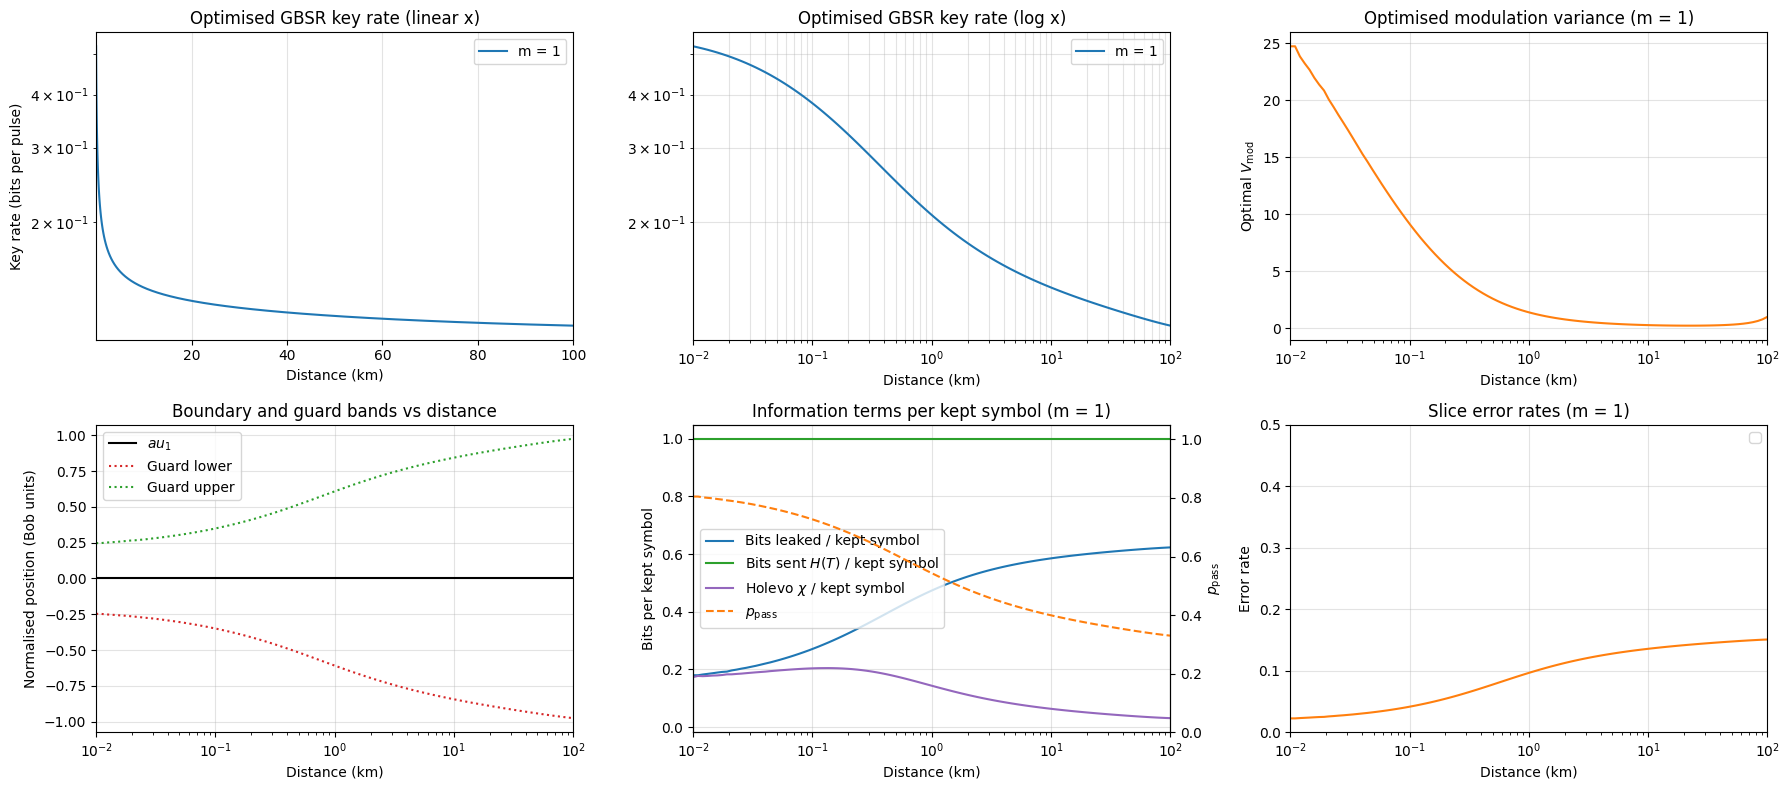

In [ ]:
m = 1

# Optimise modulation variance together with guard bands around the single boundary.
tau_gbsr_m1 = [-np.inf, 0.0, np.inf]
guard_bounds = (1e-3, 5.0)
current_guess = np.array([0.5, 0.1, 0.1], dtype=float)

gbsr_vmods_m1 = []
gbsr_guard_left_m1 = []
gbsr_guard_right_m1 = []
gbsr_key_rates_m1 = []
gbsr_etas_m1 = []
gbsr_bits_leaked_m1 = []
gbsr_bits_sent_m1 = []
gbsr_holevo_m1 = []
gbsr_p_pass_m1 = []
gbsr_raw_error_rates_m1 = []
gbsr_error_rates_m1 = []

lower_bounds = np.array([v_mod_bounds[0], guard_bounds[0], guard_bounds[0]], dtype=float)
upper_bounds = np.array([v_mod_bounds[1], guard_bounds[1], guard_bounds[1]], dtype=float)

for distance_idx, distance_km in enumerate(distances_km):
    T = fibre_transmittance(distance_km)

    def neg_key_rate(params: np.ndarray) -> float:
        v_mod, g_left, g_right = params
        gbsr_instance = GBSR(
            m=m,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        g_arr = [
            [0.0, 0.0],
            [float(g_left), float(g_right)],
            [0.0, 0.0],
        ]
        return -gbsr_instance.evaluate_key_rate_in_bits_per_pulse(tau_gbsr_m1, g_arr)

    x0 = np.clip(current_guess, lower_bounds, upper_bounds)
    bounds = [tuple(pair) for pair in zip(lower_bounds, upper_bounds)]
    result = minimize(
        neg_key_rate,
        x0=x0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol': 1e-9},
    )
    if not result.success:
        raise RuntimeError(
            f'GBSR optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt, g_left_opt, g_right_opt = result.x
    current_guess = result.x.copy()

    g_arr_opt = [
        [0.0, 0.0],
        [float(g_left_opt), float(g_right_opt)],
        [0.0, 0.0],
    ]

    gbsr_instance_opt = GBSR(
        m=m,
        modulation_variance=float(v_opt),
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    metrics = gbsr_instance_opt.evaluate_reconciliation_efficiency(tau_gbsr_m1, g_arr_opt)

    gbsr_vmods_m1.append(float(v_opt))
    gbsr_guard_left_m1.append(float(g_left_opt))
    gbsr_guard_right_m1.append(float(g_right_opt))
    gbsr_key_rates_m1.append(float(metrics['key_rate']))
    gbsr_etas_m1.append(metrics['eta'])
    gbsr_bits_leaked_m1.append(metrics['bits_leaked'])
    gbsr_bits_sent_m1.append(metrics['bits_sent'])
    gbsr_holevo_m1.append(gbsr_instance_opt._holevo_with_qct())
    gbsr_p_pass_m1.append(metrics['p_pass'])
    gbsr_raw_error_rates_m1.append(metrics['raw_error_rate'])
    gbsr_error_rates_m1.append(metrics['error_rate'])

distances = np.asarray(distances_km)
guard_left_edges = -np.asarray(gbsr_guard_left_m1)
guard_right_edges = np.asarray(gbsr_guard_right_m1)
tau_centre = np.zeros_like(distances)

bits_leaked_arr = np.asarray(gbsr_bits_leaked_m1, dtype=float)
bits_sent_arr = np.asarray(gbsr_bits_sent_m1, dtype=float)
holevo_arr = np.asarray(gbsr_holevo_m1, dtype=float)
p_pass_arr = np.asarray(gbsr_p_pass_m1, dtype=float)

bits_leaked_per_kept = np.divide(bits_leaked_arr, p_pass_arr, out=np.zeros_like(bits_leaked_arr), where=p_pass_arr > 1e-12)
bits_sent_per_kept = np.divide(bits_sent_arr, p_pass_arr, out=np.zeros_like(bits_sent_arr), where=p_pass_arr > 1e-12)
holevo_per_kept = np.divide(holevo_arr, p_pass_arr, out=np.zeros_like(holevo_arr), where=p_pass_arr > 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

ax_key_lin.plot(distances, gbsr_key_rates_m1, label='m = 1')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised GBSR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

ax_key_log.plot(distances, gbsr_key_rates_m1, label='m = 1')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised GBSR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

ax_vmod.plot(distances, gbsr_vmods_m1, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
ax_vmod.set_title('Optimised modulation variance (m = 1)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

ax_tau_plot.plot(distances, tau_centre, color='black', label=r'$	au_1$')
ax_tau_plot.plot(distances, guard_left_edges, linestyle=':', color='tab:red', label='Guard lower')
ax_tau_plot.plot(distances, guard_right_edges, linestyle=':', color='tab:green', label='Guard upper')
ax_tau_plot.set_xlabel('Distance (km)')
ax_tau_plot.set_ylabel('Normalised position (Bob units)')
ax_tau_plot.set_title('Boundary and guard bands vs distance')
ax_tau_plot.set_xscale('log')
ax_tau_plot.set_xlim(1e-2, 1e2)
if guard_right_edges.size:
    guard_span = max(np.max(np.abs(guard_left_edges)), np.max(np.abs(guard_right_edges)))
    guard_span = max(guard_span, 1e-3)
    ax_tau_plot.set_ylim(-1.1 * guard_span, 1.1 * guard_span)
ax_tau_plot.grid(True, alpha=0.35)
ax_tau_plot.legend()

ax_bits.plot(distances, bits_leaked_per_kept, color='tab:blue', label='Bits leaked / kept symbol')
ax_bits.plot(distances, bits_sent_per_kept, color='tab:green', label='Bits sent $H(T)$ / kept symbol')
ax_bits.plot(distances, holevo_per_kept, color='tab:purple', label='Holevo $\chi$ / kept symbol')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits per kept symbol')
ax_bits.set_title('Information terms per kept symbol (m = 1)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)

ax_bits_p = ax_bits.twinx()
ax_bits_p.plot(distances, p_pass_arr, color='tab:orange', linestyle='--', label=r'$p_{\mathrm{pass}}$')
ax_bits_p.set_ylabel(r'$p_{\mathrm{pass}}$')
ax_bits_p.set_ylim(0.0, 1.05)
ax_bits_p.set_xscale('log')
ax_bits_p.set_xlim(1e-2, 1e2)

bits_handles, bits_labels = ax_bits.get_legend_handles_labels()
p_pass_handles, p_pass_labels = ax_bits_p.get_legend_handles_labels()
ax_bits.legend(bits_handles + p_pass_handles, bits_labels + p_pass_labels, loc='best')

ax_errors.plot(distances, gbsr_error_rates_m1, color='tab:orange')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 1)')
ax_errors.set_xscale('log')
ax_errors.set_ylim(0.0, 0.5)
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.grid(True, alpha=0.35)

fig.tight_layout()


c:\Users\Adam\miniconda3\lib\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


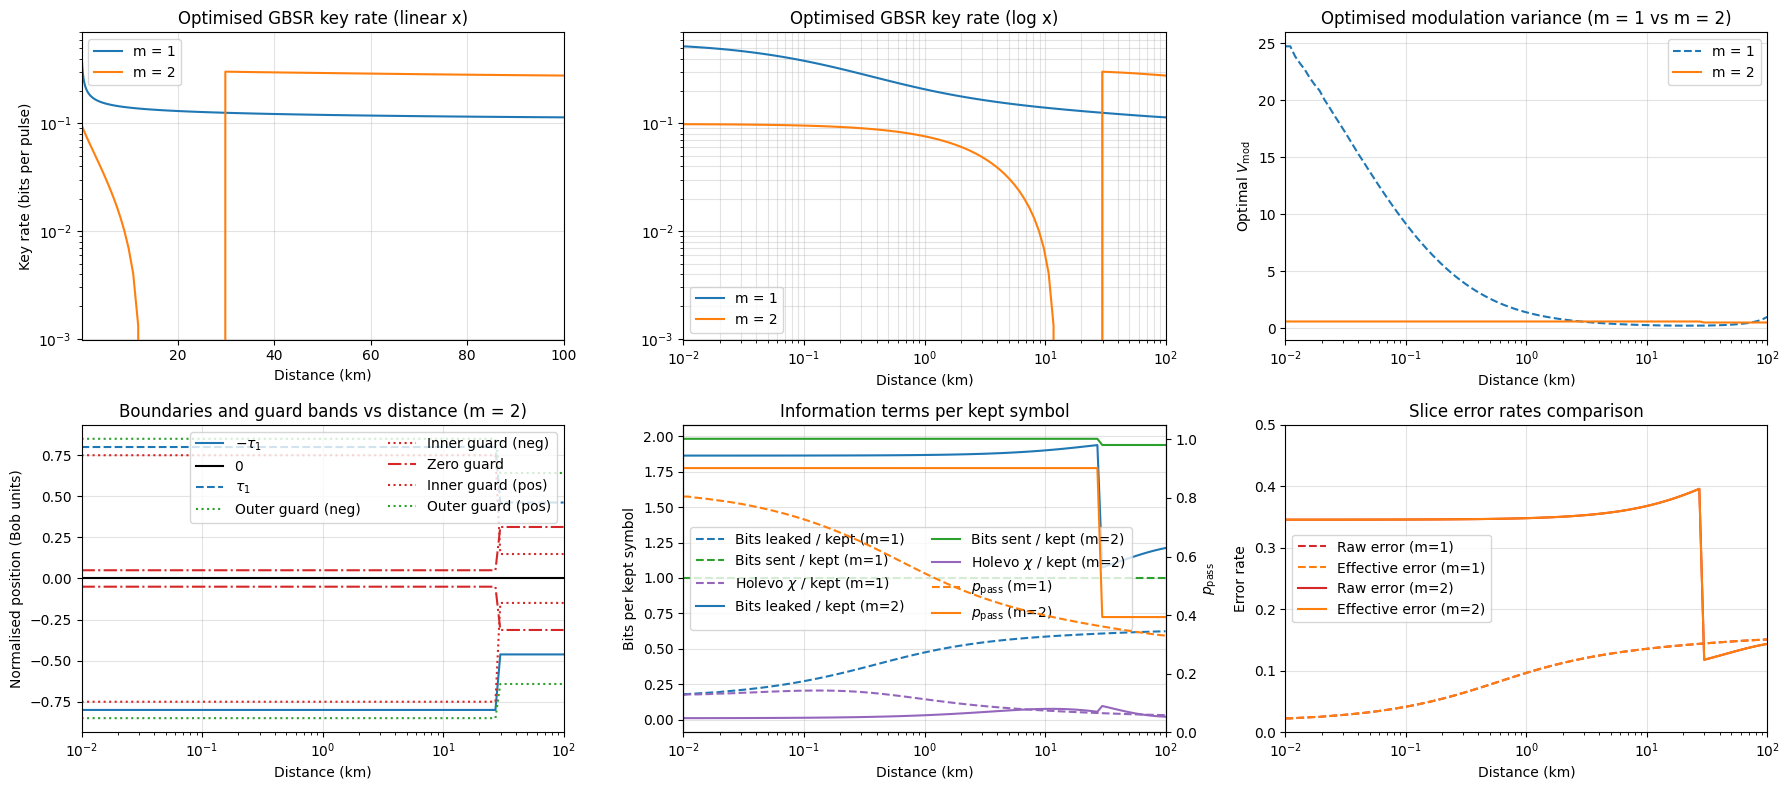

In [ ]:
m = 2

# Jointly optimise V_mod, the symmetric decision boundary, and guard bands.
tau_bounds = (1e-3, 5.0)
guard_bounds = (1e-3, 5.0)
current_guess = np.array([0.6, 0.8, 0.05, 0.05], dtype=float)

gbsr_vmods_m2 = []
gbsr_tau_m2 = []
gbsr_guard_outer_m2 = []
gbsr_guard_inner_m2 = []
gbsr_key_rates_m2 = []
gbsr_etas_m2 = []
gbsr_bits_leaked_m2 = []
gbsr_bits_sent_m2 = []
gbsr_holevo_m2 = []
gbsr_p_pass_m2 = []
gbsr_raw_error_rates_m2 = []
gbsr_error_rates_m2 = []

lower_bounds = np.array([
    v_mod_bounds[0],
    tau_bounds[0],
    guard_bounds[0],
    guard_bounds[0],
], dtype=float)
upper_bounds = np.array([
    v_mod_bounds[1],
    tau_bounds[1],
    guard_bounds[1],
    guard_bounds[1],
], dtype=float)

for distance_idx, distance_km in enumerate(distances_km):
    T = fibre_transmittance(distance_km)

    def neg_key_rate(params: np.ndarray) -> float:
        v_mod, tau_pos, g_outer, g_inner = params
        if g_inner >= tau_pos:
            return np.inf

        tau_arr = [-np.inf, -float(tau_pos), 0.0, float(tau_pos), np.inf]
        g_arr = [
            [0.0, 0.0],
            [float(g_outer), float(g_inner)],
            [float(g_inner), float(g_inner)],
            [float(g_inner), float(g_outer)],
            [0.0, 0.0],
        ]

        gbsr_instance = GBSR(
            m=m,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=excess_noise,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -gbsr_instance.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)

    x0 = np.clip(current_guess, lower_bounds, upper_bounds)
    bounds = [tuple(pair) for pair in zip(lower_bounds, upper_bounds)]

    result = minimize(
        neg_key_rate,
        x0=x0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol': 1e-9},
    )
    if not result.success:
        raise RuntimeError(
            f'GBSR optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt, tau_opt, g_outer_opt, g_inner_opt = result.x
    current_guess = result.x.copy()

    tau_arr_opt = [-np.inf, -float(tau_opt), 0.0, float(tau_opt), np.inf]
    g_arr_opt = [
        [0.0, 0.0],
        [float(g_outer_opt), float(g_inner_opt)],
        [float(g_inner_opt), float(g_inner_opt)],
        [float(g_inner_opt), float(g_outer_opt)],
        [0.0, 0.0],
    ]

    gbsr_instance_opt = GBSR(
        m=m,
        modulation_variance=float(v_opt),
        transmittance=float(T),
        excess_noise=excess_noise,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    metrics = gbsr_instance_opt.evaluate_reconciliation_efficiency(tau_arr_opt, g_arr_opt)

    gbsr_vmods_m2.append(float(v_opt))
    gbsr_tau_m2.append(float(tau_opt))
    gbsr_guard_outer_m2.append(float(g_outer_opt))
    gbsr_guard_inner_m2.append(float(g_inner_opt))
    gbsr_key_rates_m2.append(float(metrics['key_rate']))
    gbsr_etas_m2.append(metrics['eta'])
    gbsr_bits_leaked_m2.append(float(metrics['bits_leaked']))
    gbsr_bits_sent_m2.append(float(metrics['bits_sent']))
    gbsr_holevo_m2.append(gbsr_instance_opt._holevo_with_qct())
    gbsr_p_pass_m2.append(float(metrics['p_pass']))
    gbsr_raw_error_rates_m2.append(float(metrics['raw_error_rate']))
    gbsr_error_rates_m2.append(float(metrics['error_rate']))

distances = np.asarray(distances_km)
tau_vals = np.asarray(gbsr_tau_m2, dtype=float)
guard_outer_vals = np.asarray(gbsr_guard_outer_m2, dtype=float)
guard_inner_vals = np.asarray(gbsr_guard_inner_m2, dtype=float)

# Guard edge locations (Bob-normalised units).
neg_tau = -tau_vals
pos_tau = tau_vals
neg_outer_edge = neg_tau - guard_outer_vals
neg_inner_edge = neg_tau + guard_inner_vals
zero_left_edge = -guard_inner_vals
zero_right_edge = guard_inner_vals
pos_inner_edge = pos_tau - guard_inner_vals
pos_outer_edge = pos_tau + guard_outer_vals

# Information terms per kept symbol.
p_pass_m1 = np.asarray(gbsr_p_pass_m1, dtype=float)
p_pass_m2 = np.asarray(gbsr_p_pass_m2, dtype=float)

bits_leaked_per_kept_m1 = np.divide(
    np.asarray(gbsr_bits_leaked_m1, dtype=float),
    p_pass_m1,
    out=np.zeros_like(p_pass_m1),
    where=p_pass_m1 > 1e-12,
)
bits_sent_per_kept_m1 = np.divide(
    np.asarray(gbsr_bits_sent_m1, dtype=float),
    p_pass_m1,
    out=np.zeros_like(p_pass_m1),
    where=p_pass_m1 > 1e-12,
)
holevo_per_kept_m1 = np.divide(
    np.asarray(gbsr_holevo_m1, dtype=float),
    p_pass_m1,
    out=np.zeros_like(p_pass_m1),
    where=p_pass_m1 > 1e-12,
)

bits_leaked_per_kept_m2 = np.divide(
    np.asarray(gbsr_bits_leaked_m2, dtype=float),
    p_pass_m2,
    out=np.zeros_like(p_pass_m2),
    where=p_pass_m2 > 1e-12,
)
bits_sent_per_kept_m2 = np.divide(
    np.asarray(gbsr_bits_sent_m2, dtype=float),
    p_pass_m2,
    out=np.zeros_like(p_pass_m2),
    where=p_pass_m2 > 1e-12,
)
holevo_per_kept_m2 = np.divide(
    np.asarray(gbsr_holevo_m2, dtype=float),
    p_pass_m2,
    out=np.zeros_like(p_pass_m2),
    where=p_pass_m2 > 1e-12,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau_plot, ax_bits, ax_errors) = axes

ax_key_lin.plot(distances, gbsr_key_rates_m1, label='m = 1')
ax_key_lin.plot(distances, gbsr_key_rates_m2, label='m = 2')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised GBSR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

ax_key_log.plot(distances, gbsr_key_rates_m1, label='m = 1')
ax_key_log.plot(distances, gbsr_key_rates_m2, label='m = 2')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised GBSR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

ax_vmod.plot(distances, gbsr_vmods_m1, color='tab:blue', linestyle='--', label='m = 1')
ax_vmod.plot(distances, gbsr_vmods_m2, color='tab:orange', label='m = 2')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel(r'Optimal $V_{\mathrm{mod}}$')
ax_vmod.set_title('Optimised modulation variance (m = 1 vs m = 2)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)
ax_vmod.legend()

ax_tau_plot.plot(distances, neg_tau, color='tab:blue', label=r'$-\tau_1$')
ax_tau_plot.plot(distances, np.zeros_like(distances), color='black', linestyle='-', label='0')
ax_tau_plot.plot(distances, pos_tau, color='tab:blue', linestyle='--', label=r'$\tau_1$')
ax_tau_plot.plot(distances, neg_outer_edge, color='tab:green', linestyle=':', label='Outer guard (neg)')
ax_tau_plot.plot(distances, neg_inner_edge, color='tab:red', linestyle=':', label='Inner guard (neg)')
ax_tau_plot.plot(distances, zero_left_edge, color='tab:red', linestyle='-.', label='Zero guard')
ax_tau_plot.plot(distances, zero_right_edge, color='tab:red', linestyle='-.')
ax_tau_plot.plot(distances, pos_inner_edge, color='tab:red', linestyle=':', label='Inner guard (pos)')
ax_tau_plot.plot(distances, pos_outer_edge, color='tab:green', linestyle=':', label='Outer guard (pos)')
ax_tau_plot.set_xlabel('Distance (km)')
ax_tau_plot.set_ylabel('Normalised position (Bob units)')
ax_tau_plot.set_title('Boundaries and guard bands vs distance (m = 2)')
ax_tau_plot.set_xscale('log')
ax_tau_plot.set_xlim(1e-2, 1e2)
all_edges = np.concatenate([
    np.abs(neg_outer_edge),
    np.abs(neg_inner_edge),
    np.abs(zero_left_edge),
    np.abs(zero_right_edge),
    np.abs(pos_inner_edge),
    np.abs(pos_outer_edge),
])
edge_span = max(np.max(all_edges), 1e-3) if all_edges.size else 1.0
ax_tau_plot.set_ylim(-1.1 * edge_span, 1.1 * edge_span)
ax_tau_plot.grid(True, alpha=0.35)
ax_tau_plot.legend(loc='best', ncol=2)

ax_bits.plot(distances, bits_leaked_per_kept_m1, color='tab:blue', linestyle='--', label='Bits leaked / kept (m=1)')
ax_bits.plot(distances, bits_sent_per_kept_m1, color='tab:green', linestyle='--', label='Bits sent / kept (m=1)')
ax_bits.plot(distances, holevo_per_kept_m1, color='tab:purple', linestyle='--', label='Holevo $\chi$ / kept (m=1)')
ax_bits.plot(distances, bits_leaked_per_kept_m2, color='tab:blue', label='Bits leaked / kept (m=2)')
ax_bits.plot(distances, bits_sent_per_kept_m2, color='tab:green', label='Bits sent / kept (m=2)')
ax_bits.plot(distances, holevo_per_kept_m2, color='tab:purple', label='Holevo $\chi$ / kept (m=2)')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits per kept symbol')
ax_bits.set_title('Information terms per kept symbol')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)

ax_bits_p = ax_bits.twinx()
ax_bits_p.plot(distances, p_pass_m1, color='tab:orange', linestyle='--', label=r'$p_{\mathrm{pass}}$ (m=1)')
ax_bits_p.plot(distances, p_pass_m2, color='tab:orange', label=r'$p_{\mathrm{pass}}$ (m=2)')
ax_bits_p.set_ylabel(r'$p_{\mathrm{pass}}$')
ax_bits_p.set_ylim(0.0, 1.05)
ax_bits_p.set_xscale('log')
ax_bits_p.set_xlim(1e-2, 1e2)

bits_handles, bits_labels = ax_bits.get_legend_handles_labels()
p_pass_handles, p_pass_labels = ax_bits_p.get_legend_handles_labels()
ax_bits.legend(bits_handles + p_pass_handles, bits_labels + p_pass_labels, loc='best', ncol=2)

ax_errors.plot(distances, gbsr_raw_error_rates_m1, color='tab:red', linestyle='--', label='Raw error (m=1)')
ax_errors.plot(distances, gbsr_error_rates_m1, color='tab:orange', linestyle='--', label='Effective error (m=1)')
ax_errors.plot(distances, gbsr_raw_error_rates_m2, color='tab:red', label='Raw error (m=2)')
ax_errors.plot(distances, gbsr_error_rates_m2, color='tab:orange', label='Effective error (m=2)')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates comparison')
ax_errors.set_xscale('log')
ax_errors.set_ylim(0.0, 0.5)
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend(loc='best')

fig.tight_layout()
